# Stimulus Generation
Isabel Fernandez - March 24, 2026

In [1]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.signal import spectrogram, resample_poly

In [2]:
# FROM: https://github.com/Yujingoto/Goto_etal_PLoSCB2024.git
import numpy as np
from scipy.signal import bilinear, lfilter

def A_weighting(signal, fs):
    """Design of an A-weighting filter.
    b, a = A_weighting(fs) designs a digital A-weighting filter for
    sampling frequency `fs`. Usage: y = scipy.signal.lfilter(b, a, x).
    Warning: `fs` should normally be higher than 20 kHz. For example,
    fs = 48000 yields a class 1-compliant filter.
    References:
       [1] IEC/CD 1672: Electroacoustics-Sound Level Meters, Nov. 1996.
    """
    f1 = 20.598997
    f2 = 107.65265
    f3 = 737.86223
    f4 = 12194.217
    A1000 = 1.9997

    NUMs = [(2*np.pi * f4)**2 * (10**(A1000/20)), 0, 0, 0, 0]
    DENs = np.polymul([1, 4*np.pi * f4, (2*np.pi * f4)**2],
                   [1, 4*np.pi * f1, (2*np.pi * f1)**2])
    DENs = np.polymul(np.polymul(DENs, [1, 2*np.pi * f3]),
                                 [1, 2*np.pi * f2])

    b,a = bilinear(NUMs, DENs, fs)
    return lfilter(b, a, signal)

In [4]:
# Parameters
# ==========
freq = 44000                      # sampling rate (Hz)
down_freq = 2000                  # downsampled rate (Hz) 
N = 20                            # total number of noise windows

down_factor = freq // down_freq   # downsample factor
dT = 1.0                          # lenth of noise windows (sec)
n = int(freq * dT)                # number of time points in a window
n_down = int(down_freq * dT)      # number of time points in downsampled window

ref_frac = 1/3                    # fraction of noise windows that are refrence 
ref_noise_std = 0.02              # std of noise added to ref
N_ref = int(np.floor(N*ref_frac)) # number of refrence windows

ref_idx = random.sample(range(N), N_ref)

In [5]:
# Create refrence noise
# =====================
seed = 100
rng = np.random.default_rng(seed)   # seed a specific generator object
ref_stim = rng.normal(0, 1, n) # refrence noise

In [6]:
# Create raw noise for all time
# =============================
raw_stim = np.random.normal(0, 1, (N,n))
raw_stim.shape

(20, 44000)

In [7]:
# Add refence noise to raw noise
# ==============================
for i in range(N_ref):
    raw_stim[ref_idx[i],:] = ref_stim + (ref_noise_std*np.random.normal(0, 1, n))

In [8]:
# A filter and downsample stim
# ============================
down_stim = np.zeros((N,n_down))
for i in range(N):
    seg = raw_stim[i,:]                                           # raw signal
    long = np.concatenate((seg[:n//2], seg, seg[n//2::]), axis=0) # pad signal for A filtering
    A_long = A_weighting(long.squeeze(), freq)                    # A filteer
    A_seg = A_long[n//2 : n+(n//2)]                               # take signal without padding
    seg_down = A_seg[::down_factor]                               # downsample signal
    down_stim[i,:] = seg_down

In [15]:
# Compute spectogram of each noise window
# =======================================
# not sure about this
spec_stim = []
for i in range(N):
    f, t, S = spectrogram(down_stim[i,:], fs=down_freq)
    spec_stim.append(S)

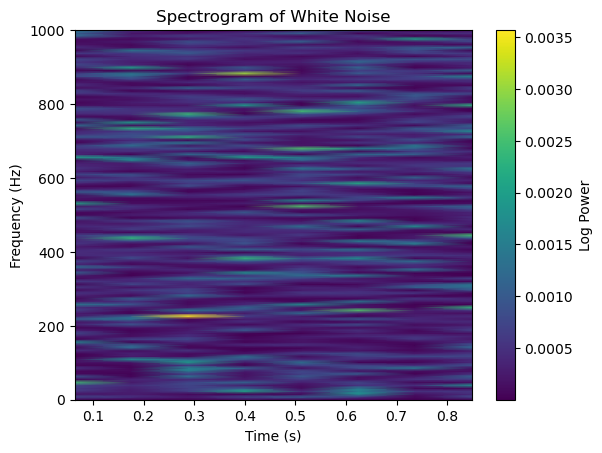

In [16]:
plt.pcolormesh(t, f, spec_stim[0], shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram of White Noise')
plt.colorbar(label='Log Power')
plt.show()